# CHECK impact of stratospheric heating

Took UKESM model from Colleen's SHeatMIP simulation. Might consider other models as well, but for that need collen's help to understand the data.

The simulations are PI-control (named GeoCntl) and idealized stratospheric heating imposed on PI-control (named GeoExpt)

All simulations are 20 years long and each simulation has 5 ensembles.

If GeoEXPT indicates a weakening of circulation then it mean StartHeat weaken circulation.

# Analysis

In [2]:
import numpy as np
import xarray as xr
import cftime
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import xarray as xr
from pathlib import Path

import sys
import os

analysis_path = os.path.abspath("../20260112_Basic_Analysis")
sys.path.append(analysis_path)

import myfunctions as mf

#Package to suppress Python warnings
import warnings
warnings.filterwarnings("ignore")


import xesmf as xe
import xarray as xr
import numpy as np

In [3]:
# ================================================================
# Utility: year-range label per experiment
# ================================================================

def _exp_year_label(exp_name):
    """Return the year-range suffix for an experiment name."""
    if exp_name in ("G6sulfur", "SSP585", "SSP245"):
        return "20212100"
    elif exp_name == "HIST":
        return "19212000"
    else:
        raise ValueError(f"Unknown experiment '{exp_name}'. "
                         "Add it to _exp_year_label().")

def _time_slice(exp_name):
    """Return the (start, end) time slice strings for an experiment."""
    if exp_name in ("G6sulfur", "SSP585", "SSP245"):
        return ("2021-01-01", "2100-12")   # 80 years
    elif exp_name == "HIST":
        return ("1921-01-01", "2000-12")   # 80 years
    else:
        raise ValueError(f"Unknown experiment '{exp_name}'.")


def roll_lon(da):
    """Roll longitude from 0-360 to -180-180."""
    da = da.assign_coords(lon=(((da.lon + 180) % 360) - 180))
    return da.sortby('lon')


def regrid_to_common(da, target_lat=None, target_lon=None):
    """Regrid a DataArray to common lat/lon grid."""
    if target_lat is None:
        target_lat = np.arange(-50, 51, 2.5)
    elif isinstance(target_lat, tuple):
        target_lat = np.arange(target_lat[0], target_lat[1]+1, 2.5)
    elif isinstance(target_lat, (int, float)):
        target_lat = np.arange(-target_lat, target_lat+1, 2.5)

    if target_lon is None:
        target_lon = np.arange(0, 360, 2.5)  # always default to full lon
    elif isinstance(target_lon, tuple):
        target_lon = np.arange(target_lon[0], target_lon[1]+1, 2.5)

    ds_out = xr.Dataset({
        'lat': (['lat'], target_lat),
        'lon': (['lon'], target_lon)
    })

    # Handle both DataSet and DataArray cases
    if isinstance(da, xr.Dataset):
        ds_in = da
    else:
        ds_in = da.to_dataset(name='data')
        
    regridder = xe.Regridder(ds_in, ds_out, method='bilinear', reuse_weights=False)
    return regridder(da) 
    
def climatology_and_uncertainty(da_year, block_size=30):
    """
    da_year: DataArray with dimension 'year'
    Returns:
        clim_mean  : mean climatology (mean of 30-yr block means)
        clim_sd    : std dev across 30-yr block means
        block_means: DataArray of each 30-yr mean
    """

    n_years = da_year.sizes["year"]
    n_blocks = n_years // block_size

    # Trim excess years
    da_trim = da_year.isel(year=slice(0, n_blocks * block_size))

    # Create block index
    block = xr.DataArray(
        np.repeat(np.arange(n_blocks), block_size),
        dims="year",
        coords={"year": da_trim.year},
        name="block"
    )

    # Compute 30-year means
    block_means = (
        da_trim
        .groupby(block)
        .mean(dim="year")*86400
    )

    # Climatological mean (mean of 30-year means)
    clim_mean = block_means.mean(dim="block")

    # Spread across 30-year climatologies
    clim_sd = block_means.std(dim="block")

    return clim_mean, clim_sd, block_means


def load_model_data(base_path, model_name, scenario, mf):
    """
    Generic loader for model data based on model and scenario.

    Parameters
    ----------
    base_path : str or Path
        File path(s) to load
    model_name : str
    scenario : str
    mf : module
        Your module with open_files functions

    Returns
    -------
    xarray.Dataset
    """
    print(str(base_path))

    if model_name == "CESM2-WACCM":
        if scenario == "G6sulfur":
            return mf.open_files_CESM_G6sulfur(base_path)
        elif scenario == "ssp585":
            return mf.open_files_CESM_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))

    elif model_name == "IPSL-CM6A-LR":
        if scenario == "ssp585":
            return mf.open_files_IPSL_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))

    else:
        return mf.open_files(str(base_path))



def load_model_data_alt_path(base_path, project, institution, model_name, scenario, ensemble, grid, mf, var_name=None):
    """
    Generic loader for model data based on model and scenario.
    
    Parameters
    ----------
    base_path : str or Path
        File path(s) to load
    model_name : str
    scenario : str
    mf : module
        Your module with open_files functions
    var_name : str, optional
        Variable name (e.g., 'ua', 'va') to check for downloaded files
    
    Returns
    -------
    xarray.Dataset
    """
    print(str(base_path))
    
    # Check if files exist at base_path, otherwise look in downloaded directory
    base_path = Path(base_path)
    downloaded_base = Path("/home/users/bidyut/data")
    
    # if not base_path.exists() or not list(base_path.glob("*.nc")):
    if not any(base_path.glob("*.nc")):
        # Try downloaded directory
        if var_name:
            # --- special-case ensemble override ---
            if model_name == "CESM2-WACCM":
                ensemble = "r1i1p1f2" if scenario == "G6sulfur" else "r1i1p1f1"
            alt_path = (downloaded_base / project / institution / model_name / scenario / ensemble / "Amon" / 
                       var_name / grid / "latest")
            print(f"Alt path is: {alt_path}")
            if alt_path.exists():
                print(f"  → Using downloaded files at: {alt_path}")
                base_path = alt_path
    
    if model_name == "CESM2-WACCM":
        if scenario == "G6sulfur":
            return mf.open_files_CESM_G6sulfur(base_path)
        elif scenario == "ssp585":
            return mf.open_files_CESM_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))
    elif model_name == "IPSL-CM6A-LR":
        if scenario == "ssp585":
            return mf.open_files_IPSL_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))
    else:
        return mf.open_files(str(base_path))


def roll_and_regrid(varname):
    return roll_lon(regrid_to_common(varname, target_lat=30))

def roll_and_regrid_3d(ds, target_lat=30):
    """Roll and regrid, handling both 2D and 3D data."""
    ds = roll_lon(ds)
    
    if 'plev' in ds.dims or 'lev' in ds.dims:
        lev_dim = 'plev' if 'plev' in ds.dims else 'lev'
        regridded_levels = []
        for lev_val in ds[lev_dim].values:
            level_data = ds.sel({lev_dim: lev_val})
            regridded = regrid_to_common(level_data, target_lat=target_lat)
            regridded_levels.append(regridded)
        return xr.concat(regridded_levels, dim=lev_dim)
    else:
        return regrid_to_common(ds, target_lat=target_lat)

In [17]:
import numpy as np
import xarray as xr
import os

# ================================================================
# CONFIGURATION
# ================================================================

EXP1 = "GeoExpt"
EXP2 = "GeoCntl"
target_var = "wap"
output_file = "/gws/ssde/j25b/impose/bidyut/analysis_transient_data/Sorted_Omega_SHeatMIP_GeoExpt_and_GeoCntl.nc"

BASE_DIR = "/gws/nopw/j04/sheat_mip/data/raw_model_output/UKESM"
MODEL_NAME = "UKESM1-0-LL"
GRID = "gn"
ENSEMBLE_MEMBERS = ["r1i1p1f2", "r2i1p1f2", "r3i1p1f2", "r4i1p1f2", "r5i1p1f2"]
EXPERIMENTS = [EXP1, EXP2]
TIME_STR = "185001-187012"  # filename date range token


def get_filepath(exp, ensemble, var):
    """Build full path to a UKESM NetCDF file."""
    filename = f"{var}_Amon_{MODEL_NAME}_{exp}_{ensemble}_{GRID}_{TIME_STR}.nc"
    return os.path.join(BASE_DIR, exp, filename)


def sort_profile(ds_wap, ds_profile, percentiles=np.arange(0, 101, 1)):
    """
    Sort vertical profiles by 500 hPa vertical velocity (w500) from low to high.
    [docstring unchanged — omitted for brevity]
    """
    if isinstance(ds_wap, xr.Dataset):
        wap = ds_wap['wap']
    else:
        wap = ds_wap

    if isinstance(ds_profile, xr.Dataset):
        profile_var_name = list(ds_profile.data_vars)[0]
        profile = ds_profile[profile_var_name]
    else:
        profile = ds_profile
        profile_var_name = profile.name or 'profile'

    # Align time coordinates
    common_times = np.intersect1d(wap.time.values, profile.time.values)
    wap = wap.sel(time=common_times)
    profile = profile.sel(time=common_times)
    print(f"  Aligned to {len(common_times)} common time steps")

    # 500 hPa vertical velocity
    w500 = wap.sel(plev=50000, method='nearest')
    print(w500.plev)
    print('*'*50)

    months = w500.time.dt.month.values
    unique_months = np.arange(1, 13)

    # Handle different pressure-level coordinate names

    print(profile.dims)
    
    if 'plev' in profile.dims:
        plev = profile.plev.values
        plev_name = 'plev'
    elif 'lev' in profile.dims:
        plev = profile.lev.values
        plev_name = 'lev'
    elif 'presnivs' in profile.dims:
        plev = profile.presnivs.values
        plev_name = 'presnivs'
    else:
        raise ValueError(f"No lev or plev. Profile dimensions found: {profile.dims}")

    n_months = len(unique_months)
    n_percentiles = len(percentiles)
    n_plev = len(plev)

    sorted_profiles = np.full((n_months, n_percentiles, n_plev), np.nan)
    w500_percentiles = np.full((n_months, n_percentiles), np.nan)
    counts = np.full((n_months, n_percentiles), 0)

    print(f"  Sorting profiles by w500 for {n_months} months...")

    for month_idx, month in enumerate(unique_months):
        month_mask = months == month
        w500_month = w500.isel(time=month_mask)
        profile_month = profile.isel(time=month_mask)

        w500_flat = w500_month.values.flatten()

        profile_reordered = profile_month.transpose('time', 'lat', 'lon', plev_name)
        profile_flat = profile_reordered.values.reshape(-1, n_plev)

        valid_mask = ~np.isnan(w500_flat)
        w500_valid = w500_flat[valid_mask]
        profile_valid = profile_flat[valid_mask, :]

        if len(w500_valid) == 0:
            print(f"    Month {month}: No valid data, skipping")
            continue

        sort_indices = np.argsort(w500_valid)
        w500_sorted = w500_valid[sort_indices]
        profile_sorted = profile_valid[sort_indices, :]

        percentile_values = np.percentile(w500_valid, percentiles)

        for p_idx in range(len(percentiles) - 1):
            p_low_val  = percentile_values[p_idx]
            p_high_val = percentile_values[p_idx + 1]

            if p_idx == 0:
                bin_mask = (w500_valid >= p_low_val) & (w500_valid <= p_high_val)
            else:
                bin_mask = (w500_valid > p_low_val) & (w500_valid <= p_high_val)

            if np.any(bin_mask):
                sorted_profiles[month_idx, p_idx, :] = np.nanmean(
                    profile_valid[bin_mask, :], axis=0
                )
                w500_percentiles[month_idx, p_idx] = np.nanmean(w500_valid[bin_mask])
                counts[month_idx, p_idx] = np.sum(bin_mask)

        # 100th percentile: single highest value
        sorted_profiles[month_idx, -1, :] = profile_sorted[-1, :]
        w500_percentiles[month_idx, -1] = w500_sorted[-1]
        counts[month_idx, -1] = 1

        print(f"    Month {month:2d}: Sorted {len(w500_valid):6d} points")

    ds_out = xr.Dataset(
        {
            'sorted_profile': (['month', 'percentile', 'plev'], sorted_profiles),
            'w500_percentile': (['month', 'percentile'], w500_percentiles),
            'count':           (['month', 'percentile'], counts),
        },
        coords={
            'month':      unique_months,
            'percentile': percentiles,
            'plev':       plev,
        },
        attrs={
            'description':     'Profiles sorted by w500 (low to high) for each month',
            'profile_variable': profile_var_name,
            'percentile_bins': f'{len(percentiles)} bins from {percentiles[0]} to {percentiles[-1]}%',
        }
    )
    return ds_out


# ================================================================
# MAIN PROCESSING LOOP
# ================================================================

if not os.path.exists(output_file):
    print('#' * 40)
    print("File does not exist — running code")
    print('#' * 40)

    # Collect results indexed as results[exp][ensemble] = ds_sorted
    results = {exp: {} for exp in EXPERIMENTS}

    for exp in EXPERIMENTS:
        for ens in ENSEMBLE_MEMBERS:

            wap_path = get_filepath(exp, ens, "wap")
            print(f"\n[{exp}] [{ens}] Loading: {wap_path}")

            # Load wap (used for both sorting key and, since target_var="wap", the profile)
            ds_wap = xr.open_dataset(wap_path)

            # Passing "wap" as ds_profile
            ds_profile = ds_wap[[target_var]]

            print(f"  [{exp}] [{ens}]: wap loaded {ds_wap.sizes['time']} months "
                  f"({ds_wap.time.values[0]} → {ds_wap.time.values[-1]})")

            print(f"  [{exp}] [{ens}]: Sorting profiles by w500...")
            ds_sorted = sort_profile(ds_wap, ds_profile, percentiles=np.arange(0, 101, 1))

            results[exp][ens] = ds_sorted

    # ================================================================
    # BUILD OUTPUT DATASET  (dims: experiment × ensemble × month × percentile × plev)
    # ================================================================

    exp_datasets = []
    for exp in EXPERIMENTS:
        ens_datasets = []
        for ens in ENSEMBLE_MEMBERS:
            ds = results[exp][ens]
            ds = ds.expand_dims({'ensemble': [ens]})
            ens_datasets.append(ds)

        ds_exp = xr.concat(ens_datasets, dim='ensemble')
        ds_exp = ds_exp.expand_dims({'experiment': [exp]})
        exp_datasets.append(ds_exp)

    ds_combined = xr.concat(exp_datasets, dim='experiment')

    # ================================================================
    # SAVE
    # ================================================================

    print(f"\nSaving to {output_file}...")
    ds_combined.to_netcdf(output_file)
    print(f"✓ Saved successfully!")
    print(f"  Dimensions : {dict(ds_combined.dims)}")
    print(f"  Variables  : {list(ds_combined.data_vars)}")

else:
    print('#' * 40)
    print(f"{output_file} already exists — skipping its computation")
    print('#' * 40)

########################################
File does not exist — running code
########################################

[GeoExpt] [r1i1p1f2] Loading: /gws/nopw/j04/sheat_mip/data/raw_model_output/UKESM/GeoExpt/wap_Amon_UKESM1-0-LL_GeoExpt_r1i1p1f2_gn_185001-187012.nc
  [GeoExpt] [r1i1p1f2]: wap loaded 252 months (1850-01-16 00:00:00 → 1870-12-16 00:00:00)
  [GeoExpt] [r1i1p1f2]: Sorting profiles by w500...
  Aligned to 252 common time steps
<xarray.DataArray 'plev' ()> Size: 8B
array(50000.)
Coordinates:
    plev     float64 8B 5e+04
Attributes:
    units:          Pa
    axis:           Z
    positive:       down
    long_name:      pressure
    standard_name:  air_pressure
**************************************************
('time', 'plev', 'lat', 'lon')
  Sorting profiles by w500 for 12 months...
    Month  1: Sorted 580608 points
    Month  2: Sorted 580608 points
    Month  3: Sorted 580608 points
    Month  4: Sorted 580608 points
    Month  5: Sorted 580608 points
    Month  6: Sor

In [77]:
def plot_sorted_profiles_comparison_diff_2D(
    ds_sorted,
    exp1=EXP1,
    exp2=EXP2,
    months=(6, 9),
    variable_name='sorted_profile',
    figsize=(15, 4),
    save_fig=False,
    fig_path=None,
    spread=False,
):
    """
    Plot 2D difference of vertical profiles sorted by w500.
    
    X-axis: percentile (0-100)
    Y-axis: pressure level (height)
    Color: difference (exp1 - exp2), ensemble mean
    """
    import numpy as np
    import matplotlib.pyplot as plt

    # ── Select & average over months ──────────────────────────────────────────
    if months[0] > months[1]:  # wrapping, e.g. NDJF: (11, 2)
        month_mask = (ds_sorted.month >= months[0]) | (ds_sorted.month <= months[1])
        data = ds_sorted[variable_name].where(month_mask, drop=True)
    else:                       # normal range, e.g. JJAS: (6, 9)
        data = ds_sorted[variable_name].sel(month=slice(months[0], months[1]))

    data = data.mean(dim='month')
    # data now has dims: (experiment, ensemble, percentile, plev)

    # ── Select experiments ────────────────────────────────────────────────────
    data_exp1 = data.sel(experiment=exp1)  # (ensemble, percentile, plev)
    data_exp2 = data.sel(experiment=exp2)  # (ensemble, percentile, plev)

    # ── Per-ensemble difference, then ensemble mean & spread ─────────────────
    diff      = data_exp1 - data_exp2          # (ensemble, percentile, plev)
    mean_diff = diff.mean(dim='ensemble')      # (percentile, plev)
    std_diff  = diff.std(dim='ensemble')       # (percentile, plev)

    # ── Coordinates ──────────────────────────────────────────────────────────
    percentiles = data.percentile.values
    plev        = data.plev.values / 100       # Pa → hPa

    PERC, PLEV = np.meshgrid(percentiles, plev)

    # Transpose to (plev, percentile) for contourf
    Z     = mean_diff.values.T * 1000          # units: e.g. Pa/s → mPa/s
    Z_std = std_diff.values.T  * 1000

    # ── Figure ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize)

    levels = np.linspace(-2.0, 2.0, 21)
    im = ax.contourf(PERC, PLEV, Z, levels=levels, cmap='RdBu_r', extend='both')
    ax.contour(PERC, PLEV, Z, levels=levels[::2],
               colors='black', linewidths=0.5, alpha=0.3)
    ax.contour(PERC, PLEV, Z, levels=[0],
               colors='black', linewidths=1.5)

    # # Optional spread hatching (±1 std envelope)
    if spread:
        # Hatches on top
        import matplotlib as mpl
        
        # Set hatch styling before drawing
        mpl.rcParams['hatch.color'] = (0, 0, 0, 0.25)
        mpl.rcParams['hatch.linewidth'] = 0.5   # controls density/thickness
        
        cs = ax.contourf(PERC, PLEV, np.abs(Z) / (Z_std + 1e-10),
                         levels=[0, 1], colors='gray',
                         hatches=['//'], alpha=0.3)
        
        # Reset after so it doesn't affect other plots
        mpl.rcParams['hatch.color'] = 'black'
        mpl.rcParams['hatch.linewidth'] = 1.0

    # #A more rigorous t-test approach across the 5 ensemble members:
    # if spread:
    #     from scipy import stats
    #     # diff has dims (ensemble, percentile, plev)
    #     t_stat, p_value = stats.ttest_1samp(diff.values, popmean=0, axis=0)
    #     # p_value shape: (percentile, plev)
        
    #     # Hatch where NOT significant (p > 0.05)
    #     mpl.rcParams['hatch.color'] = (0, 0, 0, 0.25)
    #     mpl.rcParams['hatch.linewidth'] = 0.5   # controls density/thickness
    #     ax.contourf(PERC, PLEV, p_value.T,
    #                 levels=[0.05, 1.0], colors='none',
    #                 hatches=['////'], alpha=0.0)
    #     # Reset after so it doesn't affect other plots
    #     mpl.rcParams['hatch.color'] = 'black'
    #     mpl.rcParams['hatch.linewidth'] = 1.0

    # ── Colorbar ─────────────────────────────────────────────────────────────
    cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.02)
    cbar.set_label(
        f'Δ{variable_name.replace("_", " ").title()} ({exp1} − {exp2})  [mPa s⁻¹]',
        fontsize=11
    )

    # ── Axes formatting ───────────────────────────────────────────────────────
    ax.invert_yaxis()
    ax.set_ylabel('Pressure (hPa)', fontsize=12)
    ax.set_xlabel('w500 Percentile', fontsize=12)
    ax.set_yticks([1000, 850, 700, 500, 300, 200, 100])
    ax.set_yticklabels(['1000', '850', '700', '500', '300', '200', '100'])
    ax.set_xlim(0, 100)
    ax.set_xticks(np.arange(0, 101, 10))
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

    # Ascent / descent shading
    ax.axvspan(0,  50,  alpha=0.05, color='blue', zorder=0)
    ax.axvspan(50, 100, alpha=0.05, color='red',  zorder=0)
    ax.text(15, plev.max() * 0.85, 'Ascent',  ha='center',
            fontsize=9, color='blue', alpha=0.7)
    ax.text(75, plev.max() * 0.85, 'Descent', ha='center',
            fontsize=9, color='red',  alpha=0.7)

    # ── Title ─────────────────────────────────────────────────────────────────
    month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
                   7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
    if months[0] > months[1]:
        month_seq = list(range(months[0], 13)) + list(range(1, months[1] + 1))
    else:
        month_seq = list(range(months[0], months[1] + 1))
    month_str = '-'.join(month_names[m] for m in month_seq)

    n_ens = diff.sizes['ensemble']
    ax.set_title(
        f'Vertical $\omega$ Profile Difference: {exp1} − {exp2}\n'
        f'Sorted by $\omega$500  |  {month_str}  |  Ensemble mean (n={n_ens})',
        fontsize=12, fontweight='bold'
    )

    plt.tight_layout()

    if save_fig:
        path = fig_path or f'sorted_profile_2D_{exp1}_minus_{exp2}_{month_str}.png'
        fig.savefig(path, dpi=300, bbox_inches='tight')
        print(f"Figure saved → {path}")

    plt.show()
    return fig, ax, mean_diff, std_diff


# Load output data

In [78]:
# Load the dataset
ds_sorted = xr.open_dataset(output_file)

# Plot

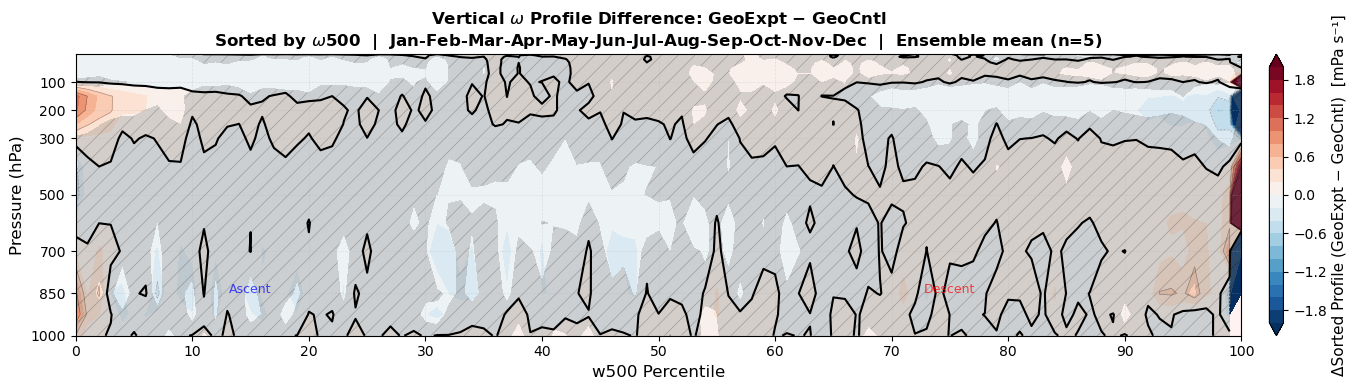

In [81]:
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax, mean, std = plot_sorted_profiles_comparison_diff_2D(
    ds_sorted,
    exp1=EXP1,
    exp2=EXP2,
    months=(1, 12),   # all months; change to e.g. (6,9) for JJAS
    save_fig=False,
    spread=True,
)

# DIAGNOSTIC CHECKS

CHECK 1: Pressure level used for sorting
Available plev values (Pa): [100000.  92500.  85000.  70000.  60000.  50000.  40000.  30000.  25000.
  20000.  15000.  10000.   7000.   5000.   3000.   2000.   1000.    500.
    100.]
Available plev values (hPa): [1000.  925.  850.  700.  600.  500.  400.  300.  250.  200.  150.  100.
   70.   50.   30.   20.   10.    5.    1.]

Level selected by sel(plev=50000, method='nearest'): 50000.0 Pa = 500.0 hPa
  → Is this 500 hPa? ✓ YES

CHECK 2: Each ensemble sorted by its own w500
Dataset dimensions: {'experiment': 2, 'ensemble': 5, 'month': 12, 'percentile': 101, 'plev': 19}
Variables: ['sorted_profile', 'w500_percentile', 'count']

w500_percentile at percentile=0, 50, 100 for each ensemble × experiment:
Exp          Ensemble          p0 (Pa)     p50 (Pa)    p100 (Pa)
----------------------------------------------------------------
GeoExpt      r1i1p1f2          -0.1598       0.0042       0.4582
GeoExpt      r2i1p1f2          -0.1614       0.0040   

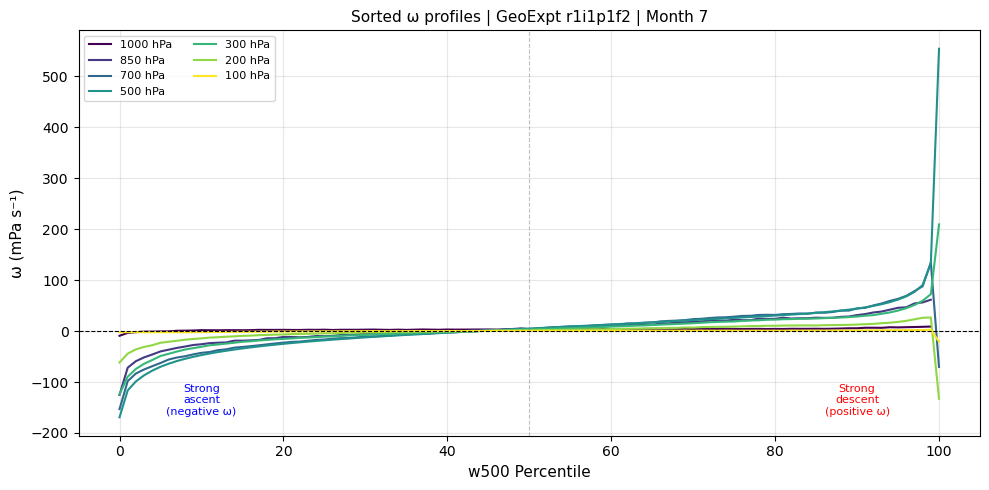

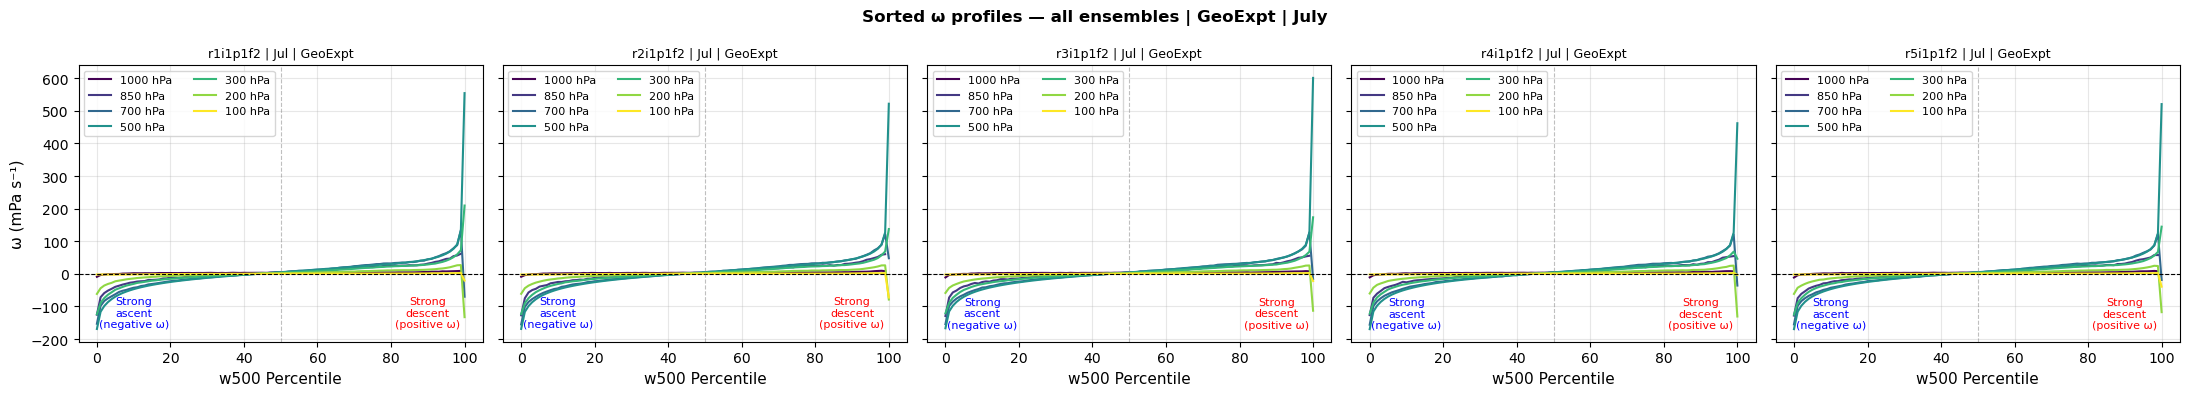

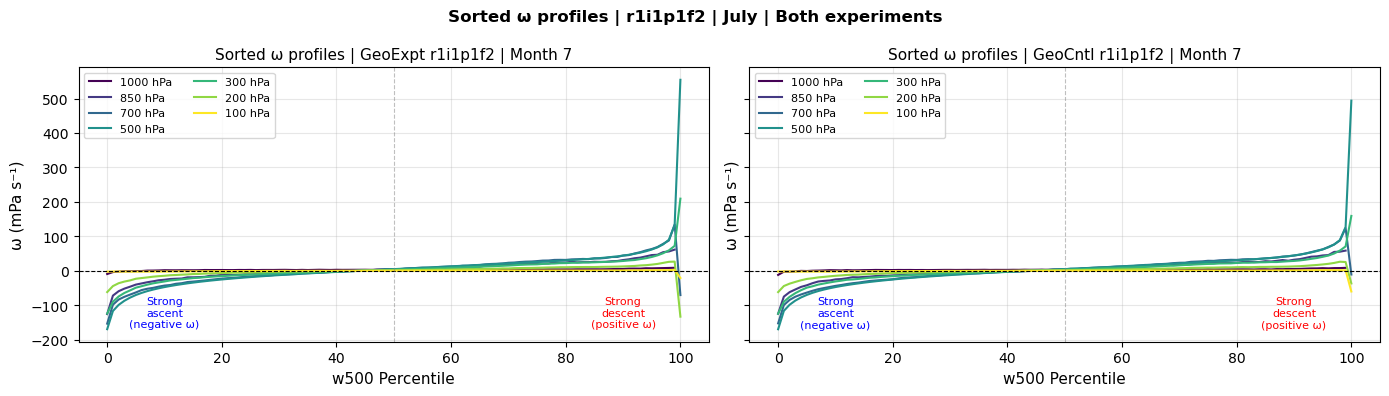

In [82]:
# ================================================================
# DIAGNOSTIC CHECKS
# ================================================================

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ----------------------------------------------------------------
# CHECK 1: Confirm w500 sorting level
# ----------------------------------------------------------------
print("=" * 60)
print("CHECK 1: Pressure level used for sorting")
print("=" * 60)

# Open one file and check plev coordinate
test_path = get_filepath(EXP1, ENSEMBLE_MEMBERS[0], "wap")
ds_test = xr.open_dataset(test_path)[['wap']]

print(f"Available plev values (Pa): {ds_test.plev.values}")
print(f"Available plev values (hPa): {ds_test.plev.values / 100}")

# Check which level sel(plev=50000, method='nearest') actually picks
w500_check = ds_test['wap'].sel(plev=50000, method='nearest')
print(f"\nLevel selected by sel(plev=50000, method='nearest'): "
      f"{w500_check.plev.values} Pa = {w500_check.plev.values/100} hPa")
print(f"  → Is this 500 hPa? {'✓ YES' if abs(w500_check.plev.values - 50000) < 1000 else '✗ NO — CHECK UNITS!'}")


# ----------------------------------------------------------------
# CHECK 2: Confirm each ensemble is sorted by its own w500
# ----------------------------------------------------------------
print("\n" + "=" * 60)
print("CHECK 2: Each ensemble sorted by its own w500")
print("=" * 60)

# This is structural — verify by checking w500_percentile values differ across ensembles
ds_nc = xr.open_dataset(output_file)
print(f"Dataset dimensions: {dict(ds_nc.dims)}")
print(f"Variables: {list(ds_nc.data_vars)}")

print("\nw500_percentile at percentile=0, 50, 100 for each ensemble × experiment:")
print(f"{'Exp':<12} {'Ensemble':<12} {'p0 (Pa)':>12} {'p50 (Pa)':>12} {'p100 (Pa)':>12}")
print("-" * 64)
for exp in [EXP1, EXP2]:
    for ens in ENSEMBLE_MEMBERS:
        w = ds_nc['w500_percentile'].sel(experiment=exp, ensemble=ens)
        print(f"{exp:<12} {ens:<12} "
              f"{w.sel(percentile=0).mean('month').values:>12.4f} "
              f"{w.sel(percentile=50).mean('month').values:>12.4f} "
              f"{w.sel(percentile=100).mean('month').values:>12.4f}")
    print()

# Confirm ensembles differ from each other (i.e., not all identical)
w_exp1 = ds_nc['w500_percentile'].sel(experiment=EXP1)
spread_across_ens = w_exp1.std(dim='ensemble').mean().values
print(f"Std of w500_percentile across ensembles ({EXP1}): {spread_across_ens:.6f} Pa")
print(f"  → {'✓ Ensembles have different w500 distributions (good)' if spread_across_ens > 0 else '✗ All ensembles identical — something is wrong'}")


# ----------------------------------------------------------------
# CHECK 3: Plot raw sorted profile for one ensemble member
#           to verify ascent/descent structure makes physical sense
# ----------------------------------------------------------------
print("\n" + "=" * 60)
print("CHECK 3: Plot sorted wap profiles for one ensemble member")
print("=" * 60)

def plot_sorted_profile_raw(ds_nc, exp, ens, month=7, ax=None):
    """
    Plot the sorted wap profile (sorted_profile vs percentile) at each pressure level
    for a single ensemble member and month. 
    Physically we expect:
      - Low percentiles (strong ascent)  → large negative wap
      - High percentiles (strong descent) → large positive wap
    """
    profile = ds_nc['sorted_profile'].sel(
        experiment=exp, ensemble=ens, month=month
    )  # (percentile, plev)
    
    w500_perc = ds_nc['w500_percentile'].sel(
        experiment=exp, ensemble=ens, month=month
    )  # (percentile,)
    
    percentiles = ds_nc.percentile.values
    plev_hPa    = ds_nc.plev.values / 100

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))
        standalone = True
    else:
        standalone = False

    # Plot a selection of pressure levels
    levels_to_plot = [100000, 85000, 70000, 50000, 30000, 20000, 10000]  # Pa
    colors = plt.cm.viridis(np.linspace(0, 1, len(levels_to_plot)))

    for lev, col in zip(levels_to_plot, colors):
        # Find nearest plev
        lev_idx = np.argmin(np.abs(ds_nc.plev.values - lev))
        actual_lev = ds_nc.plev.values[lev_idx]
        ax.plot(percentiles, profile.isel(plev=lev_idx).values * 1000,
                label=f'{actual_lev/100:.0f} hPa', color=col, linewidth=1.5)

    ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
    ax.axvline(50, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xlabel('w500 Percentile', fontsize=11)
    ax.set_ylabel('ω (mPa s⁻¹)', fontsize=11)
    ax.set_title(f'Sorted ω profiles | {exp} {ens} | Month {month}', fontsize=11)
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)

    # Annotate expected behaviour
    ax.text(10, ax.get_ylim()[0] * 0.8, 'Strong\nascent\n(negative ω)',
            ha='center', fontsize=8, color='blue')
    ax.text(90, ax.get_ylim()[0] * 0.8, 'Strong\ndescent\n(positive ω)',
            ha='center', fontsize=8, color='red')

    if standalone:
        plt.tight_layout()
        plt.show()
    return ax


# 3a: Single panel — one ensemble, one month
plot_sorted_profile_raw(ds_nc, exp=EXP1, ens='r1i1p1f2', month=7)

# 3b: All 5 ensembles side by side for July, GeoExpt
fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=True, sharex=True)
for ax, ens in zip(axes, ENSEMBLE_MEMBERS):
    plot_sorted_profile_raw(ds_nc, exp=EXP1, ens=ens, month=7, ax=ax)
    ax.set_title(f'{ens} | Jul | {EXP1}', fontsize=9)
axes[0].set_ylabel('ω (mPa s⁻¹)', fontsize=11)
for ax in axes[1:]:
    ax.set_ylabel('')
fig.suptitle(f'Sorted ω profiles — all ensembles | {EXP1} | July', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 3c: Both experiments for r1i1p1f2, July
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True, sharex=True)
for ax, exp in zip(axes, [EXP1, EXP2]):
    plot_sorted_profile_raw(ds_nc, exp=exp, ens='r1i1p1f2', month=7, ax=ax)
fig.suptitle('Sorted ω profiles | r1i1p1f2 | July | Both experiments',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# END